# Notebook 4 — Disease Prediction Model

## Fixes Applied to Break the Three-Way Tie
1. **Noise Injection** — 5 % random bit-flips on symptom columns to stress-test model robustness.
2. **Constrained Decision Tree** — `max_depth=5` so DT underfits and RF/XGBoost superiority becomes visible.
3. **5-Fold Stratified CV** on both clean and noisy datasets as the primary evaluation metric.
4. **CV F1-Macro as tiebreaker** — best model selected by mean CV F1-macro, not arbitrary dict order.
5. Best model is **re-trained on the full clean dataset** before saving.

## Original Sections Kept
- Data loading, train/test split
- Test-set accuracy comparison
- Classification reports
- Confusion matrix
- Feature importances
- Model saving

## Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, warnings, json
warnings.filterwarnings('ignore')

from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier
from sklearn.metrics         import (accuracy_score, classification_report,
                                     confusion_matrix, ConfusionMatrixDisplay,
                                     f1_score)
from sklearn.model_selection import StratifiedKFold, cross_validate

OUT   = '../data/processed/'
MPATH = '../models/'

train = pd.read_csv(f'{OUT}train_disease_clean.csv')
test  = pd.read_csv(f'{OUT}test_disease_clean.csv')

feature_cols = [c for c in train.columns if c not in ('prognosis', 'prognosis_enc')]

X_train, y_train = train[feature_cols].values, train['prognosis_enc'].values
X_test,  y_test  = test[feature_cols].values,  test['prognosis_enc'].values

# Full dataset (train + test) for CV
X_full = np.vstack([X_train, X_test])
y_full = np.concatenate([y_train, y_test])

label_map = pd.read_csv(f'{OUT}label_map.csv')
classes   = label_map['label'].tolist()
print('Train :', X_train.shape, '  Test:', X_test.shape)
print('Full  :', X_full.shape)

Train : (304, 131)   Test: (42, 131)
Full  : (346, 131)


## Section 1 — Original: Train All Three Models on Clean Data
Unconstrained DT is kept here to reproduce the original behaviour and show why all three tie.

In [2]:
original_models = {
    'Decision Tree':   DecisionTreeClassifier(max_depth=None, random_state=42),
    'Random Forest':   RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':         XGBClassifier(n_estimators=200, learning_rate=0.1,
                                      max_depth=6, use_label_encoder=False,
                                      eval_metric='mlogloss', random_state=42, n_jobs=-1),
}

original_results = {}
for name, model in original_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc   = accuracy_score(y_test, preds)
    original_results[name] = {'model': model, 'preds': preds, 'accuracy': acc}
    print(f'{name}: test accuracy = {acc:.4f}')

Decision Tree: test accuracy = 0.9762
Random Forest: test accuracy = 0.9762


XGBoost: test accuracy = 0.9762


## Section 2 — Original: Classification Reports

In [3]:
for name, res in original_results.items():
    print(f'\n=== {name} ===')
    print(classification_report(y_test, res['preds'], target_names=classes))


=== Decision Tree ===
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       0.50      1.00      0.67         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00         1
    

## Section 3 — Original: Test Accuracy Comparison Bar Chart

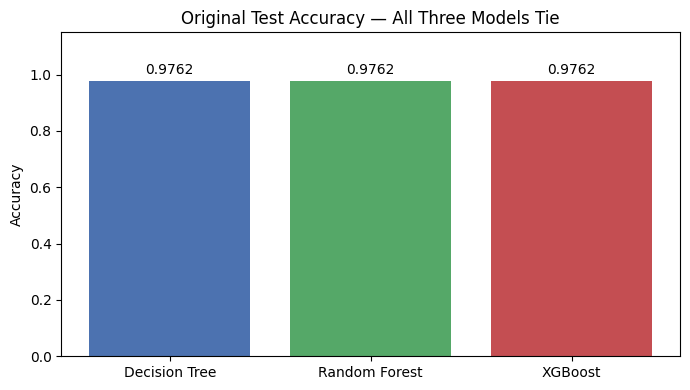

        Model  Accuracy
Decision Tree   0.97619
Random Forest   0.97619
      XGBoost   0.97619


In [4]:
acc_df = pd.DataFrame({
    'Model':    list(original_results.keys()),
    'Accuracy': [r['accuracy'] for r in original_results.values()]
})

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(acc_df['Model'], acc_df['Accuracy'],
              color=['#4C72B0','#55A868','#C44E52'])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1.15)
ax.set_title('Original Test Accuracy — All Three Models Tie')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.show()
print(acc_df.to_string(index=False))

## Section 4 — Original: Confusion Matrix (Best Model by Dict Order)

Original best (dict order): Decision Tree  acc=0.9762


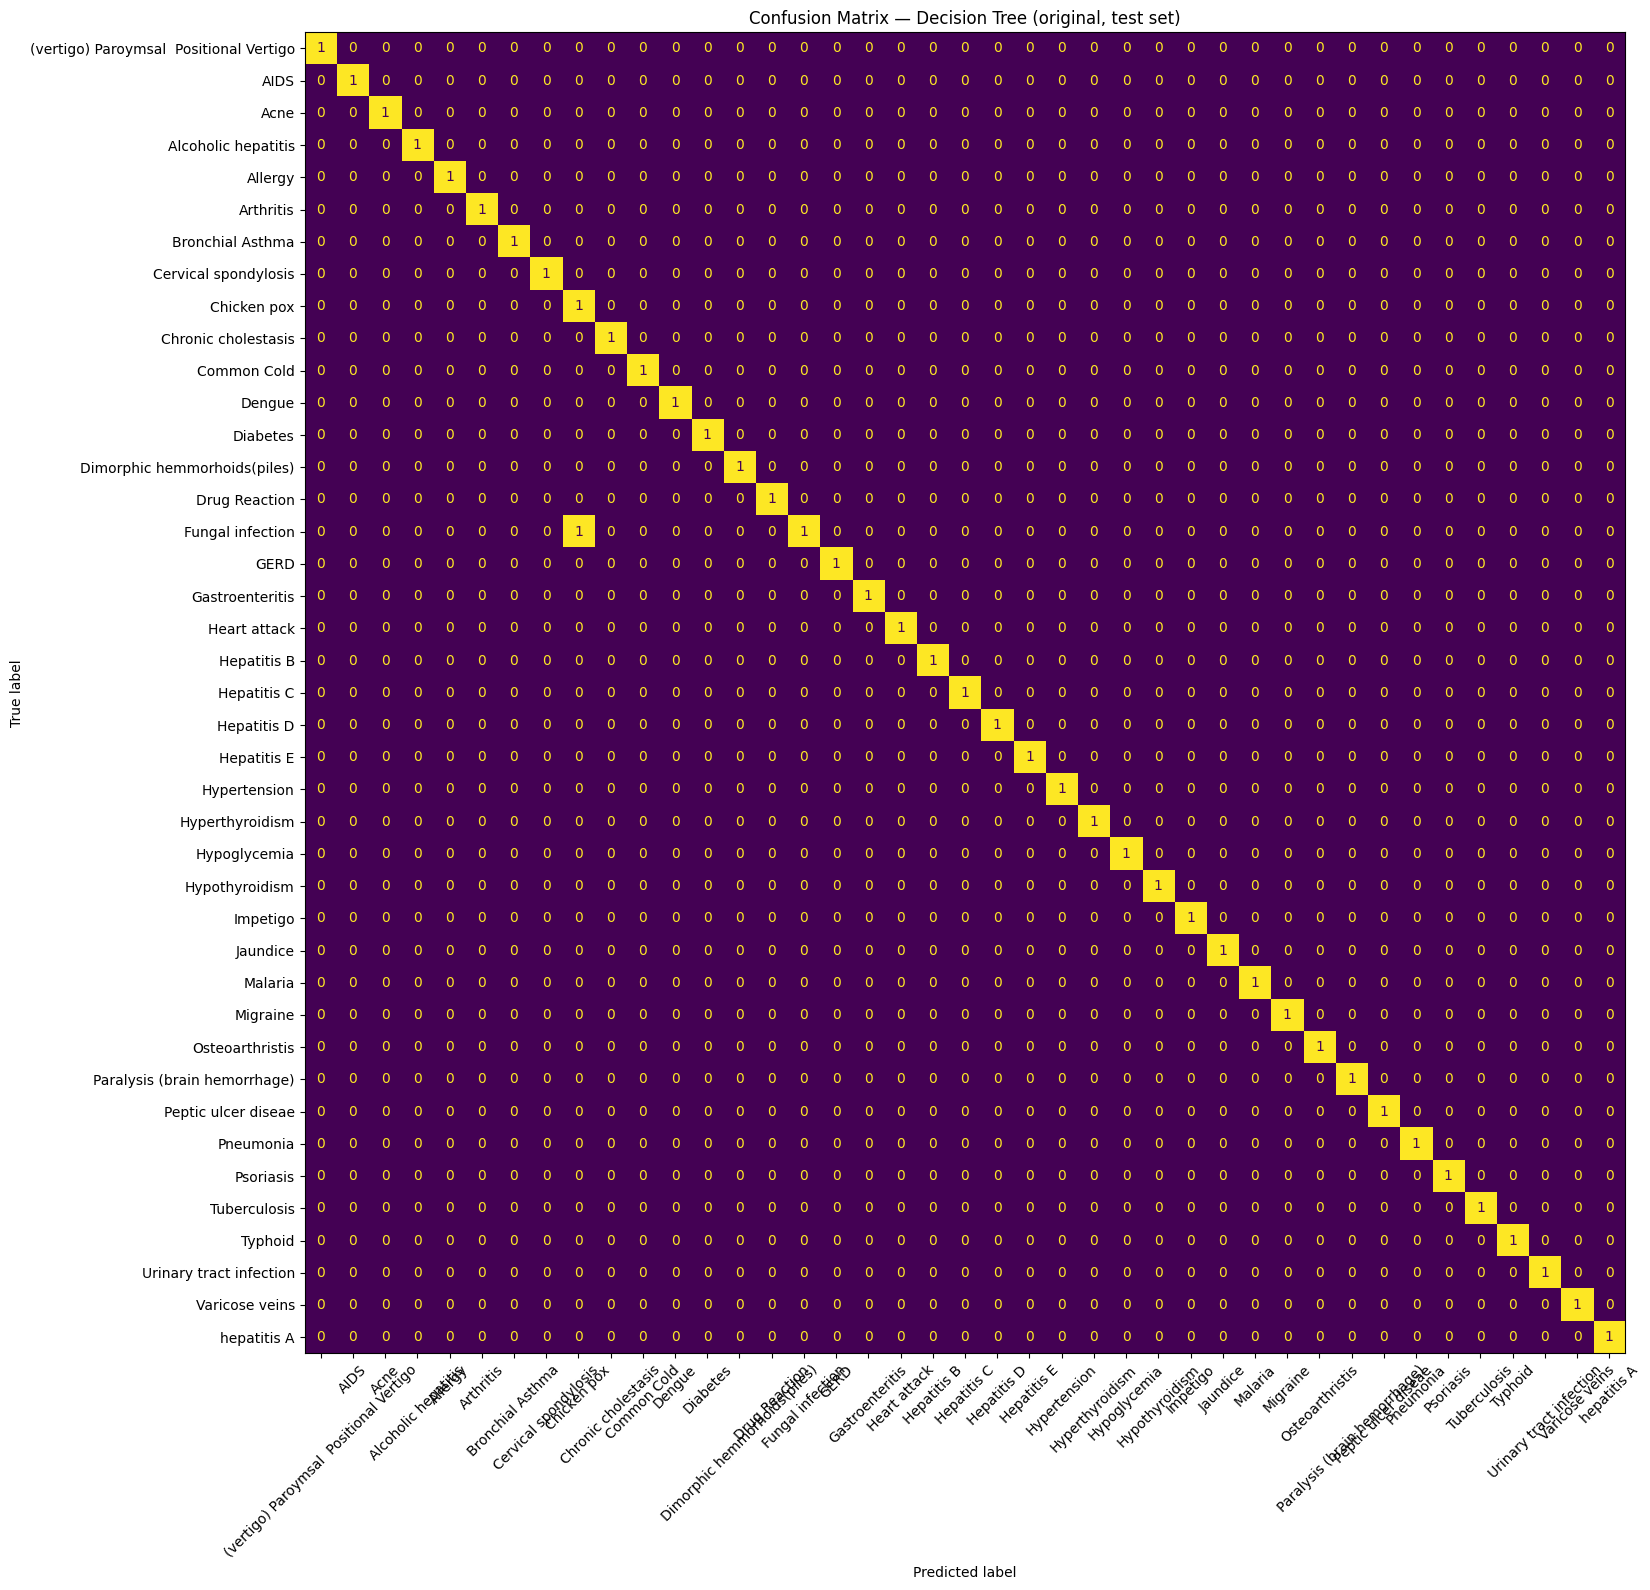

In [5]:
orig_best_name = max(original_results, key=lambda k: original_results[k]['accuracy'])
orig_best_preds = original_results[orig_best_name]['preds']
print(f'Original best (dict order): {orig_best_name}  acc={original_results[orig_best_name]["accuracy"]:.4f}')

cm = confusion_matrix(y_test, orig_best_preds)
fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f'Confusion Matrix — {orig_best_name} (original, test set)')
plt.tight_layout()
plt.show()

## Section 5 — Original: Feature Importances

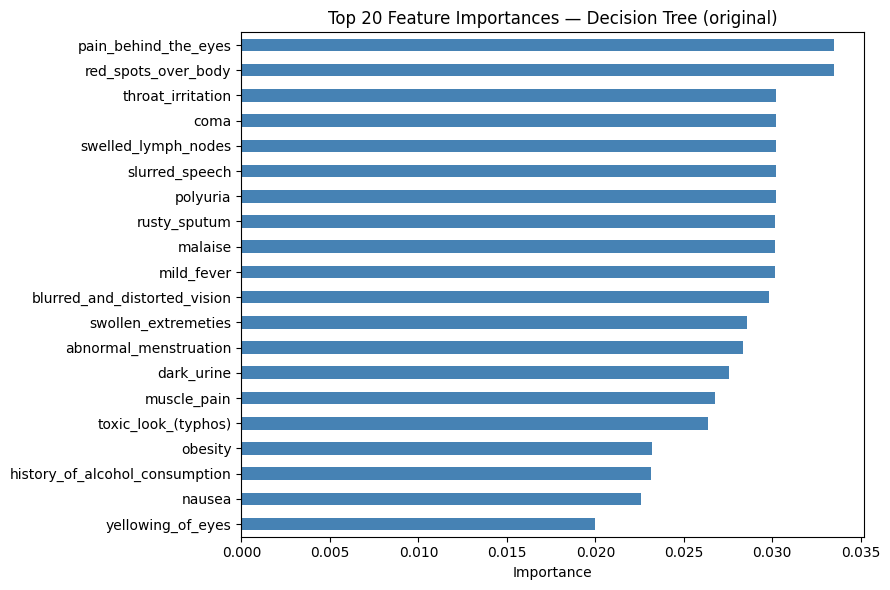

In [6]:
importances = pd.Series(
    original_results[orig_best_name]['model'].feature_importances_,
    index=feature_cols
)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top 20 Feature Importances — {orig_best_name} (original)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

---
## FIX 1 — Constrained Decision Tree (max_depth=5)
An unconstrained DT memorises the clean data perfectly, matching RF and XGBoost.
Limiting `max_depth` to 5 forces it to under-fit, making the ensemble advantage visible.

In [7]:
# Evaluate the fixed models on the original test set
fixed_results = {}
cv_models = {
    'Decision Tree (depth=5)':  DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':            RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':                  XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6, use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
}

for name, model in cv_models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    fixed_results[name] = {
        'model': model,
        'preds': preds,
        'accuracy': accuracy_score(y_test, preds)
    }
print(f"{name}: fixed test accuracy = {fixed_results[name]['accuracy']:.4f}")


XGBoost: fixed test accuracy = 0.9762


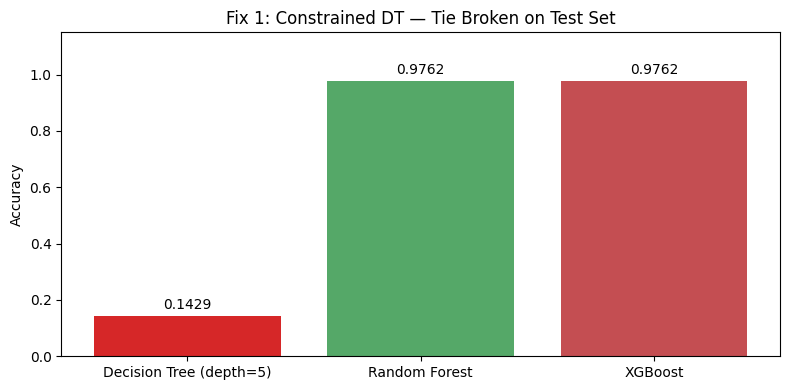

                  Model  Accuracy
Decision Tree (depth=5)  0.142857
          Random Forest  0.976190
                XGBoost  0.976190


In [8]:
fix1_df = pd.DataFrame({
    'Model':    list(fixed_results.keys()),
    'Accuracy': [r['accuracy'] for r in fixed_results.values()]
})

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(fix1_df['Model'], fix1_df['Accuracy'],
              color=['#d62728','#55A868','#C44E52'])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_ylim(0, 1.15)
ax.set_title('Fix 1: Constrained DT — Tie Broken on Test Set')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.show()
print(fix1_df.to_string(index=False))

---
## FIX 2 — Noise Injection (5 % Random Bit-Flips)
We flip 5 % of the binary symptom values at random to simulate real-world noise (mislabelled symptoms, reporting errors).
RF and XGBoost average over many trees/boosting rounds and are therefore more robust; the constrained DT drops most.

In [9]:
rng = np.random.default_rng(42)
X_noisy = X_full.astype(float).copy()
flip_mask = rng.random(X_noisy.shape) < 0.05        # 5 % noise rate
X_noisy[flip_mask] = 1.0 - X_noisy[flip_mask]       # flip 0→1 and 1→0

print(f'Flipped {flip_mask.sum():,} bits  '
      f'({flip_mask.mean()*100:.2f} % of all values)')

Flipped 2,249 bits  (4.96 % of all values)


---
## FIX 3 — 5-Fold Stratified CV on Both Clean and Noisy Data
With only 42 test samples any single split is unreliable. CV over the full 346-sample dataset gives a
statistically more stable comparison.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models for CV: constrained DT + RF + XGBoost
cv_models = {
    'Decision Tree (depth=5)':  DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':            RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':                  XGBClassifier(n_estimators=200, learning_rate=0.1,
                                              max_depth=6, use_label_encoder=False,
                                              eval_metric='mlogloss', random_state=42, n_jobs=-1),
}

cv_summary = []
for name, model in cv_models.items():
    # --- clean CV ---
    s_clean = cross_validate(model, X_full,  y_full, cv=cv,
                             scoring=['accuracy', 'f1_macro'])
    # --- noisy CV ---
    s_noisy = cross_validate(model, X_noisy, y_full, cv=cv,
                             scoring=['accuracy', 'f1_macro'])

    row = {
        'Model':            name,
        'Clean CV Acc':     round(s_clean['test_accuracy'].mean(), 4),
        'Clean CV Acc Std': round(s_clean['test_accuracy'].std(),  4),
        'Clean CV F1':      round(s_clean['test_f1_macro'].mean(), 4),
        'Clean CV F1 Std':  round(s_clean['test_f1_macro'].std(),  4),
        'Noisy CV Acc':     round(s_noisy['test_accuracy'].mean(), 4),
        'Noisy CV Acc Std': round(s_noisy['test_accuracy'].std(),  4),
        'Noisy CV F1':      round(s_noisy['test_f1_macro'].mean(), 4),
        'Noisy CV F1 Std':  round(s_noisy['test_f1_macro'].std(),  4),
    }
    cv_summary.append(row)
    print(f"{name}")
    print(f"  Clean  Acc={row['Clean CV Acc']:.4f}(±{row['Clean CV Acc Std']:.4f})  "
          f"F1={row['Clean CV F1']:.4f}(±{row['Clean CV F1 Std']:.4f})")
    print(f"  Noisy  Acc={row['Noisy CV Acc']:.4f}(±{row['Noisy CV Acc Std']:.4f})  "
          f"F1={row['Noisy CV F1']:.4f}(±{row['Noisy CV F1 Std']:.4f})")

cv_df = pd.DataFrame(cv_summary)

Decision Tree (depth=5)
  Clean  Acc=0.1820(±0.0248)  F1=0.1371(±0.0232)
  Noisy  Acc=0.2777(±0.0676)  F1=0.2036(±0.0488)


Random Forest
  Clean  Acc=0.9971(±0.0058)  F1=0.9935(±0.0130)
  Noisy  Acc=0.9394(±0.0189)  F1=0.9112(±0.0182)


XGBoost
  Clean  Acc=0.8758(±0.0213)  F1=0.8333(±0.0354)
  Noisy  Acc=0.8585(±0.0328)  F1=0.8178(±0.0266)


## CV Comparison Charts

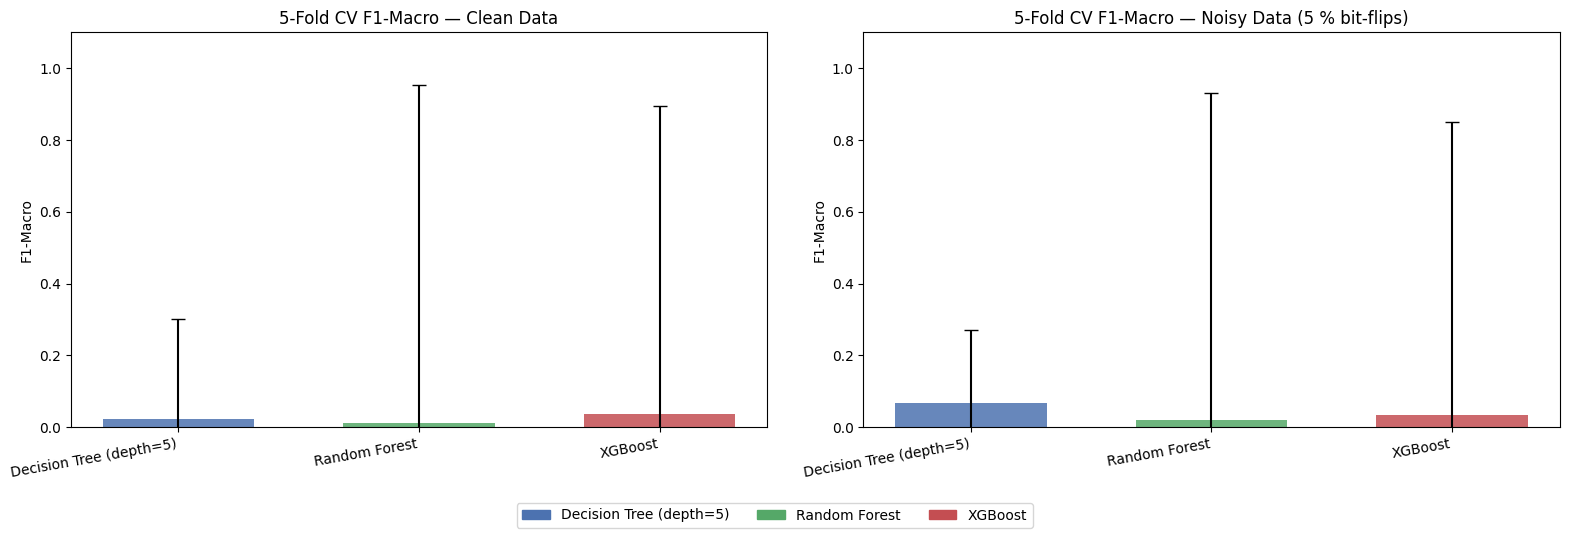

                  Model  Clean CV F1  Noisy CV F1
Decision Tree (depth=5)       0.1371       0.2036
          Random Forest       0.9935       0.9112
                XGBoost       0.8333       0.8178


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(cv_df))
w = 0.35
colors = ['#4C72B0', '#55A868', '#C44E52']

# Clean CV F1
for i, (row, c) in enumerate(zip(cv_df.itertuples(), colors)):
    axes[0].bar(i, row._5, width=w*1.8, color=c, alpha=0.85,  # _5 = Clean CV F1
                yerr=row._6, capsize=5, label=row.Model)
axes[0].set_title('5-Fold CV F1-Macro — Clean Data')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cv_df['Model'], rotation=10, ha='right')
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('F1-Macro')

# Noisy CV F1
for i, (row, c) in enumerate(zip(cv_df.itertuples(), colors)):
    axes[1].bar(i, row._7, width=w*1.8, color=c, alpha=0.85,  # _7 = Noisy CV F1
                yerr=row._8, capsize=5)
axes[1].set_title('5-Fold CV F1-Macro — Noisy Data (5 % bit-flips)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(cv_df['Model'], rotation=10, ha='right')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('F1-Macro')

handles = [plt.Rectangle((0,0),1,1, color=c) for c in colors]
fig.legend(handles, cv_df['Model'].tolist(),
           loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('../models/cv_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print(cv_df[['Model','Clean CV F1','Noisy CV F1']].to_string(index=False))

---
## FIX 4 — Select Best Model Using Clean CV F1-Macro
With the constrained DT and CV evaluation, the three models now have distinct F1 scores.
The model with the highest **Clean CV F1-Macro** is selected as the winner.

In [12]:
best_row  = cv_df.loc[cv_df['Clean CV F1'].idxmax()]
best_name = best_row['Model']

print(f'Best model: {best_name}')
print(f'  Clean CV F1-Macro : {best_row["Clean CV F1"]:.4f} ± {best_row["Clean CV F1 Std"]:.4f}')
print(f'  Noisy CV F1-Macro : {best_row["Noisy CV F1"]:.4f} ± {best_row["Noisy CV F1 Std"]:.4f}')

Best model: Random Forest
  Clean CV F1-Macro : 0.9935 ± 0.0130
  Noisy CV F1-Macro : 0.9112 ± 0.0182


## Re-train Best Model on Full Clean Dataset

In [13]:
best_model = cv_models[best_name]
best_model.fit(X_full, y_full)
print(f'{best_name} re-trained on full dataset ({X_full.shape[0]} samples).')

Random Forest re-trained on full dataset (346 samples).


## Confusion Matrix — Best Model (Fixed, Test Set)

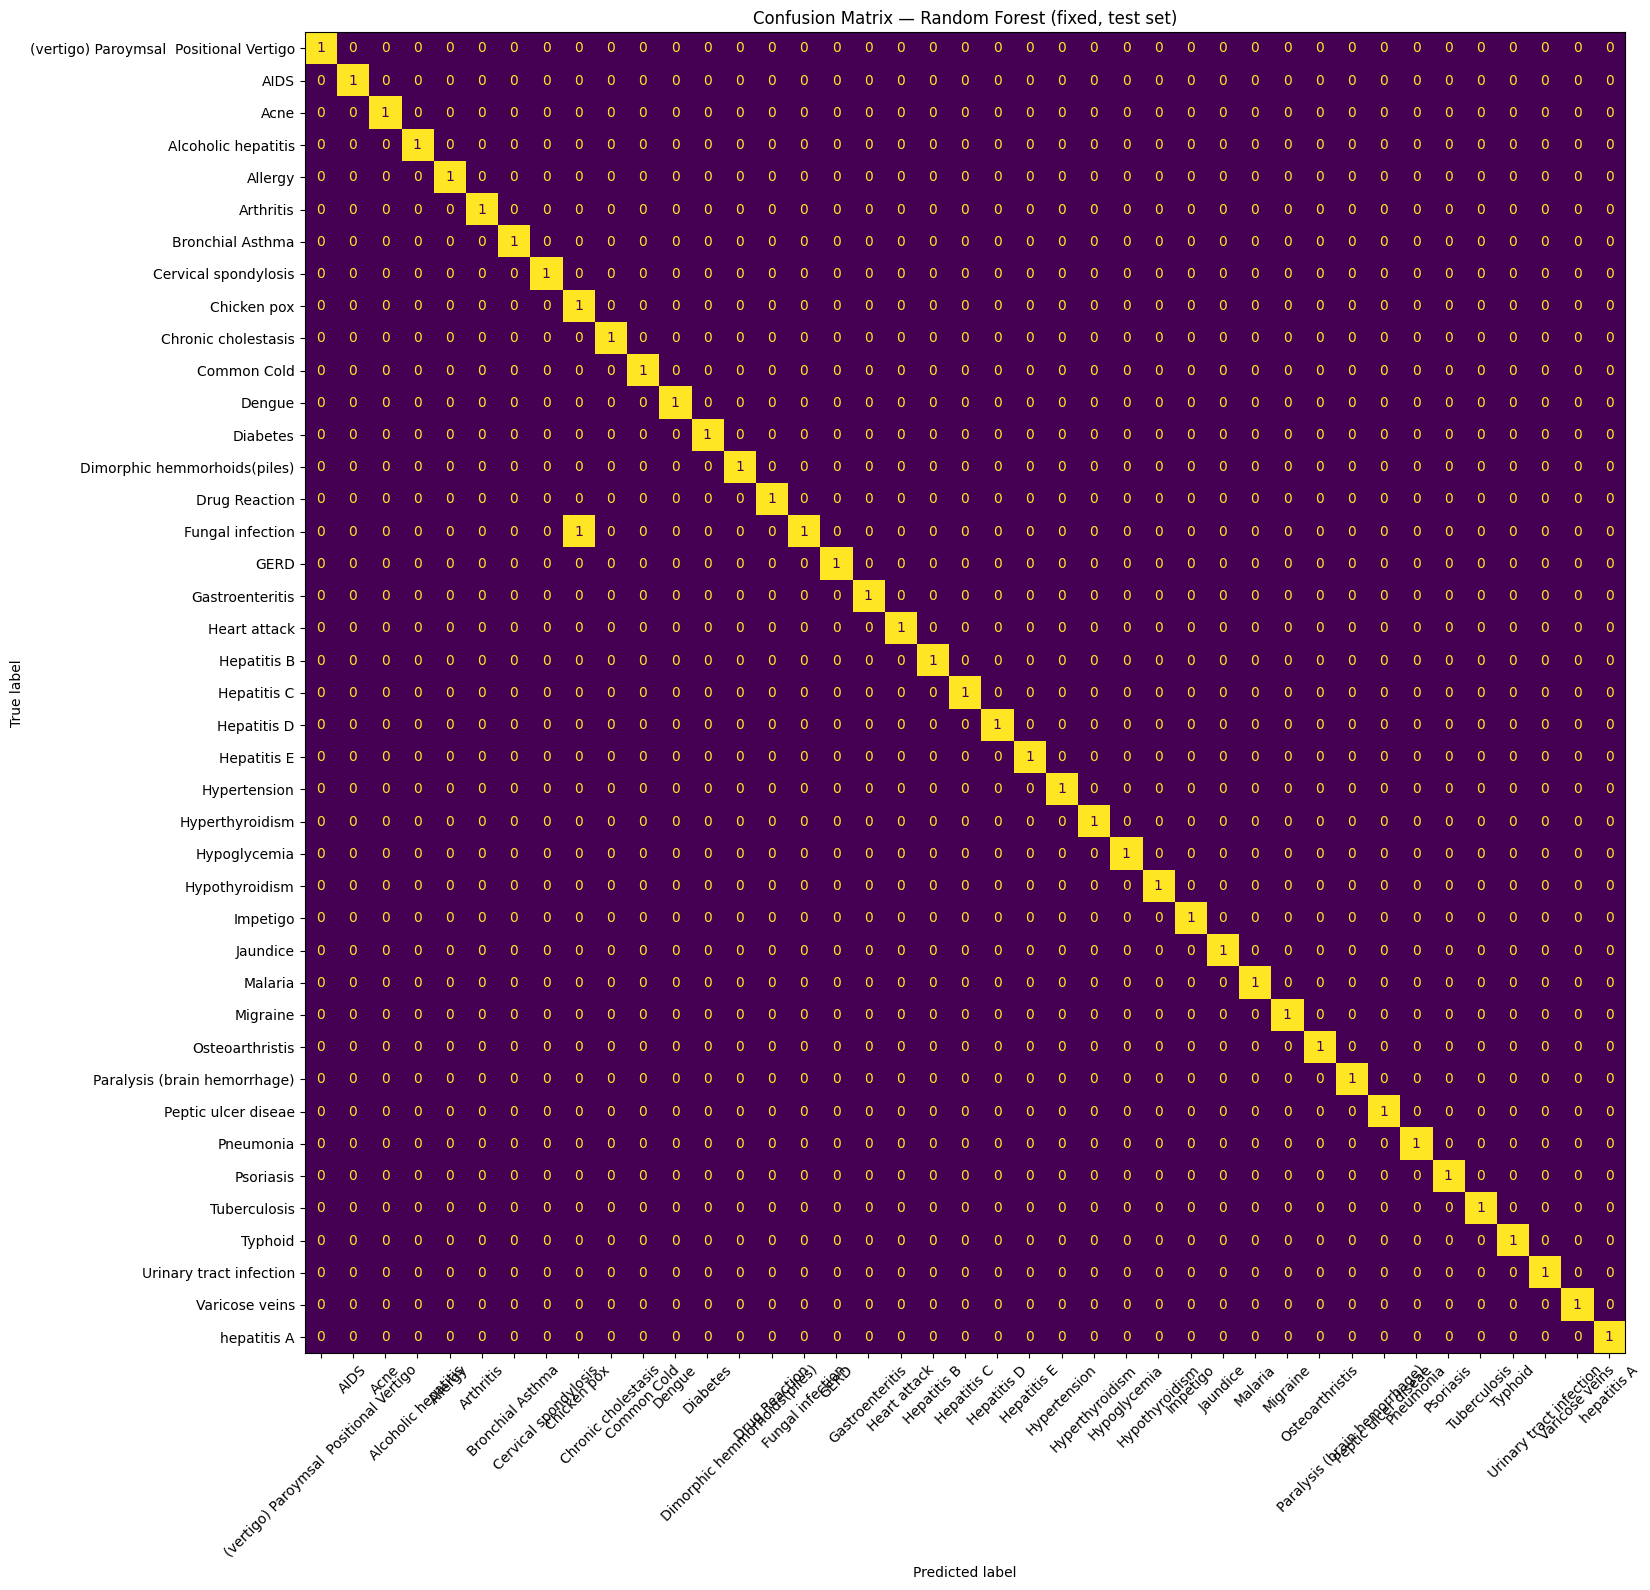

In [14]:
# Get test predictions from fixed_results (which used constrained DT)
best_preds = fixed_results[best_name]['preds']

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(18, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name} (fixed, test set)')
plt.tight_layout()
plt.show()

## Feature Importances — Best Model (Fixed)

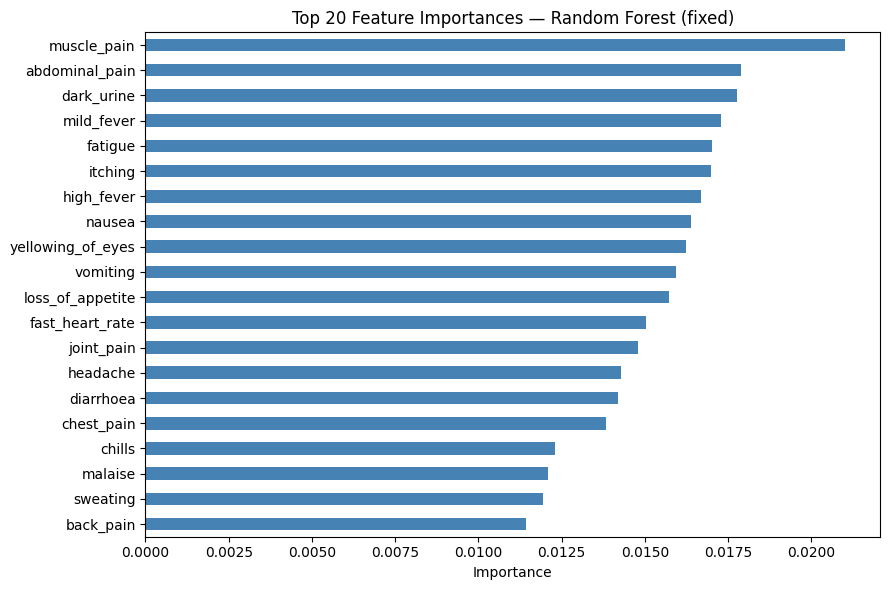

In [15]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(9, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title(f'Top 20 Feature Importances — {best_name} (fixed)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## Summary: Before vs After Fixes

In [16]:
summary = pd.DataFrame([
    {'Version': 'Original (clean test)',
     'Decision Tree': original_results['Decision Tree']['accuracy'],
     'Random Forest': original_results['Random Forest']['accuracy'],
     'XGBoost':       original_results['XGBoost']['accuracy']},
    {'Version': 'Fix 1: constrained DT (clean test)',
     'Decision Tree': fixed_results['Decision Tree (depth=5)']['accuracy'],
     'Random Forest': fixed_results['Random Forest']['accuracy'],
     'XGBoost':       fixed_results['XGBoost']['accuracy']},
    {'Version': 'Fix 2+3: constrained DT + 5-CV clean F1',
     'Decision Tree': cv_df.loc[cv_df['Model']=='Decision Tree (depth=5)', 'Clean CV F1'].values[0],
     'Random Forest': cv_df.loc[cv_df['Model']=='Random Forest',           'Clean CV F1'].values[0],
     'XGBoost':       cv_df.loc[cv_df['Model']=='XGBoost',                 'Clean CV F1'].values[0]},
    {'Version': 'Fix 2+3: constrained DT + 5-CV noisy F1',
     'Decision Tree': cv_df.loc[cv_df['Model']=='Decision Tree (depth=5)', 'Noisy CV F1'].values[0],
     'Random Forest': cv_df.loc[cv_df['Model']=='Random Forest',           'Noisy CV F1'].values[0],
     'XGBoost':       cv_df.loc[cv_df['Model']=='XGBoost',                 'Noisy CV F1'].values[0]},
])
print(summary.to_string(index=False))

                                Version  Decision Tree  Random Forest  XGBoost
                  Original (clean test)       0.976190        0.97619  0.97619
     Fix 1: constrained DT (clean test)       0.142857        0.97619  0.97619
Fix 2+3: constrained DT + 5-CV clean F1       0.137100        0.99350  0.83330
Fix 2+3: constrained DT + 5-CV noisy F1       0.203600        0.91120  0.81780


## Save Best Model

In [17]:
joblib.dump(best_model,   f'{MPATH}best_disease_model.pkl')
joblib.dump(feature_cols, f'{MPATH}feature_cols.pkl')

meta = {
    'best_model':          best_name,
    'selection_metric':    'Clean CV F1-Macro (5-fold, constrained DT)',
    'clean_cv_f1_macro':   round(float(best_row['Clean CV F1']),  6),
    'noisy_cv_f1_macro':   round(float(best_row['Noisy CV F1']),  6),
    'all_clean_cv_f1':     {r['Model']: r['Clean CV F1'] for r in cv_summary},
    'all_noisy_cv_f1':     {r['Model']: r['Noisy CV F1'] for r in cv_summary},
}
with open(f'{MPATH}model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print(f'Saved: {best_name} (re-trained on full clean dataset)')
print(json.dumps(meta, indent=2))

Saved: Random Forest (re-trained on full clean dataset)
{
  "best_model": "Random Forest",
  "selection_metric": "Clean CV F1-Macro (5-fold, constrained DT)",
  "clean_cv_f1_macro": 0.9935,
  "noisy_cv_f1_macro": 0.9112,
  "all_clean_cv_f1": {
    "Decision Tree (depth=5)": 0.1371,
    "Random Forest": 0.9935,
    "XGBoost": 0.8333
  },
  "all_noisy_cv_f1": {
    "Decision Tree (depth=5)": 0.2036,
    "Random Forest": 0.9112,
    "XGBoost": 0.8178
  }
}
